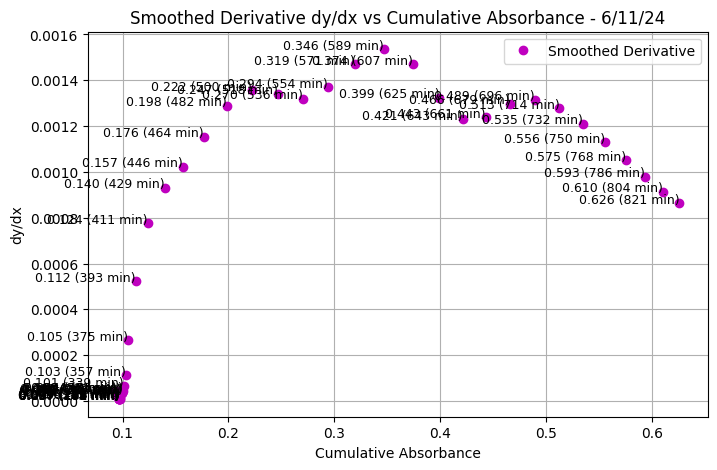

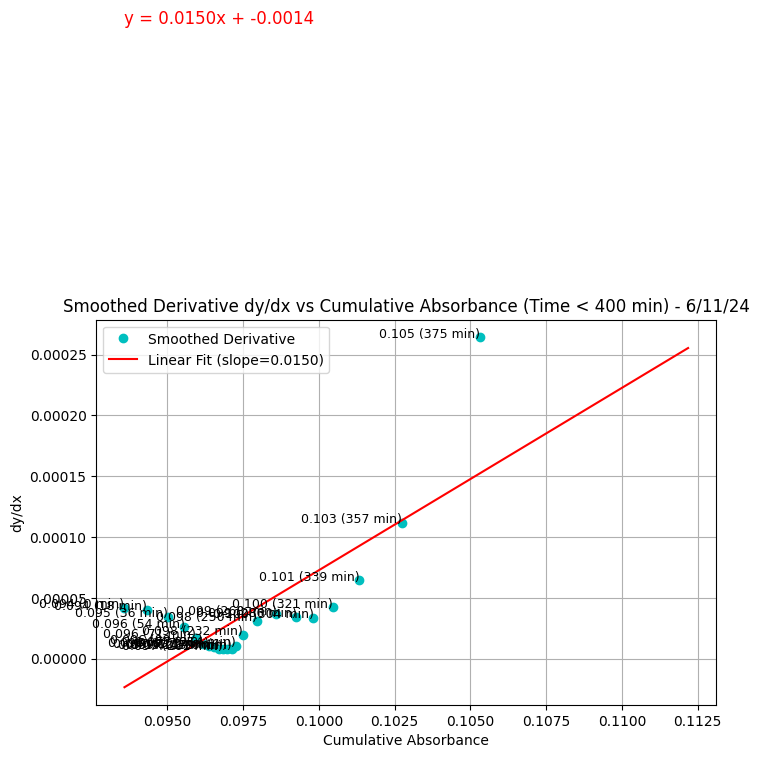

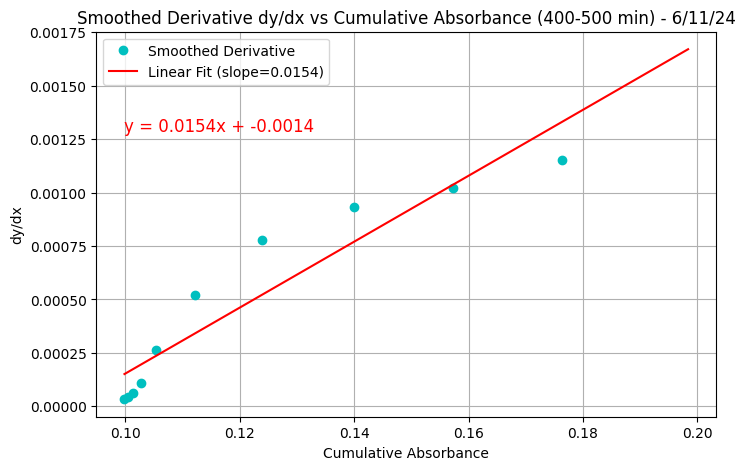

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress
import pandas as pd

# Given Data
data = {
    "6/11/24": [
        ("10:55", 0.092), ("11:40", 0.096), ("12:16", 0.098), ("12:45", 0.097),
        ("13:20", 0.098), ("14:04", 0.098), ("14:35", 0.099), ("15:10", 0.099),
        ("15:45", 0.112), ("16:30", 0.107), ("17:09", 0.126), ("17:43", 0.166),
        ("18:09", 0.512), ("18:55", 0.624), ("19:30", 0.93), ("20:34", 1.006),
        ("21:06", 1.317), ("21:30", 1.374), ("22:00", 1.12), ("22:41", 1.413),
        ("23:14", 1.47), ("01:00", 1.339), ("01:30", 1.349)
    ]

}

# Function to convert time to minutes since the first recorded time of the day
def convert_time_to_minutes(times):
    base_time = datetime.datetime.strptime(times[0], "%H:%M")
    return [(datetime.datetime.strptime(t, "%H:%M") - base_time).seconds / 60 for t in times]

# Process and plot data for each date
for date, values in data.items():
    times, absorbance = zip(*values)
    x_values = convert_time_to_minutes(times)
    y_values = np.array(absorbance)

    # Regularize x-axis and interpolate
    x_new = np.linspace(min(x_values), max(x_values), num=50)
    y_interpolated = np.interp(x_new, x_values, y_values)

    # Moving average smoothing
    window_size = 3
    y_smooth = np.convolve(y_interpolated, np.ones(window_size)/window_size, mode='valid')
    x_smooth = x_new[:len(y_smooth)]

    # Compute cumulative absorbance
    y_cumulative = np.cumsum(y_smooth) / np.arange(1, len(y_smooth) + 1)

    # Compute derivatives from cumulative absorbance
    dy_dx_smooth = np.gradient(y_cumulative, x_smooth)

    # Annotate y-values with corresponding x-values
    y_annotated = [f"{y:.3f} ({x:.0f} min)" for x, y in zip(x_smooth, y_cumulative)]

    # Plot dy/dx vs y with y-values labeled with time
    plt.figure(figsize=(8, 5))
    plt.plot(y_cumulative[:-1], dy_dx_smooth[:-1], 'mo', label='Smoothed Derivative')
    for i in range(len(y_cumulative) - 1):
        plt.text(y_cumulative[i], dy_dx_smooth[i], y_annotated[i], fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance - {date}')
    plt.legend()
    plt.grid()
    plt.show()

    # Filter data for time < 400 minutes
    mask = np.array(x_smooth) < 400
    x_filtered = np.array(x_smooth)[mask]
    y_filtered = np.array(y_cumulative)[mask]
    dy_dx_filtered = np.array(dy_dx_smooth)[mask]

    # Linear fit for dy/dx vs y graph (time < 400 min)
    slope, intercept, _, _, _ = linregress(y_filtered[:-1], dy_dx_filtered[:-1])
    y_fit = np.linspace(min(y_filtered), max(y_filtered), 50)
    dy_dx_fit = slope * y_fit + intercept

    # Plot filtered dy/dx vs y with linear fit (time < 400 min)
    plt.figure(figsize=(8, 5))
    plt.plot(y_filtered[:-1], dy_dx_filtered[:-1], 'co', label='Smoothed Derivative')
    plt.plot(y_fit, dy_dx_fit, 'r-', label=f'Linear Fit (slope={slope:.4f})')
    for i in range(len(y_filtered) - 1):
        plt.text(y_filtered[i], dy_dx_filtered[i], f"{y_filtered[i]:.3f} ({x_filtered[i]:.0f} min)", fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (Time < 400 min) - {date}')
    plt.legend()
    plt.grid()
    plt.text(min(y_filtered), max(dy_dx_filtered), f"y = {slope:.4f}x + {intercept:.4f}", fontsize=12, color='red')
    plt.show()

    # Filter data for time 300-500 min
    mask_300_500 = (np.array(x_smooth) >= 300) & (np.array(x_smooth) < 500)
    x_filtered_300_500 = np.array(x_smooth)[mask_300_500]
    y_filtered_300_500 = np.array(y_cumulative)[mask_300_500]
    dy_dx_filtered_300_500 = np.array(dy_dx_smooth)[mask_300_500]

    if len(y_filtered_300_500) > 1:
        slope_300_500, intercept_300_500, _, _, _ = linregress(y_filtered_300_500[:-1], dy_dx_filtered_300_500[:-1])
        y_fit_300_500 = np.linspace(min(y_filtered_300_500), max(y_filtered_300_500), 50)
        dy_dx_fit_300_500 = slope_300_500 * y_fit_300_500 + intercept_300_500

        plt.figure(figsize=(8, 5))
        plt.plot(y_filtered_300_500[:-1], dy_dx_filtered_300_500[:-1], 'co', label='Smoothed Derivative')
        plt.plot(y_fit_300_500, dy_dx_fit_300_500, 'r-', label=f'Linear Fit (slope={slope_300_500:.4f})')
        plt.xlabel('Cumulative Absorbance')
        plt.ylabel('dy/dx')
        plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (400-500 min) - {date}')
        plt.legend()
        plt.grid()
        plt.text(min(y_filtered_300_500), max(dy_dx_filtered_300_500), f"y = {slope_300_500:.4f}x + {intercept_300_500:.4f}", fontsize=12, color='red')
        plt.show()

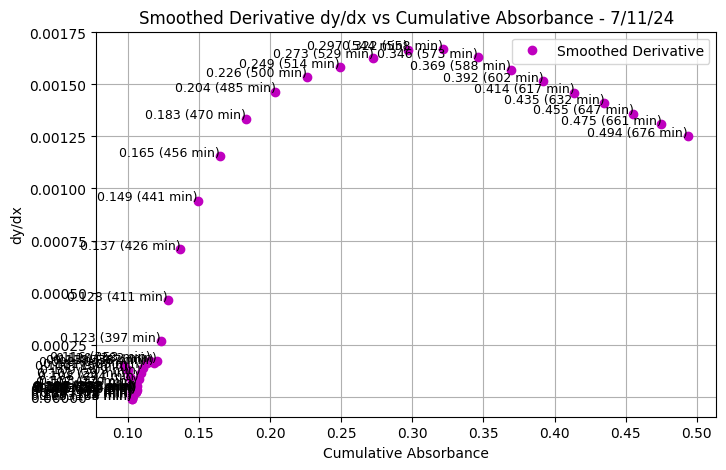

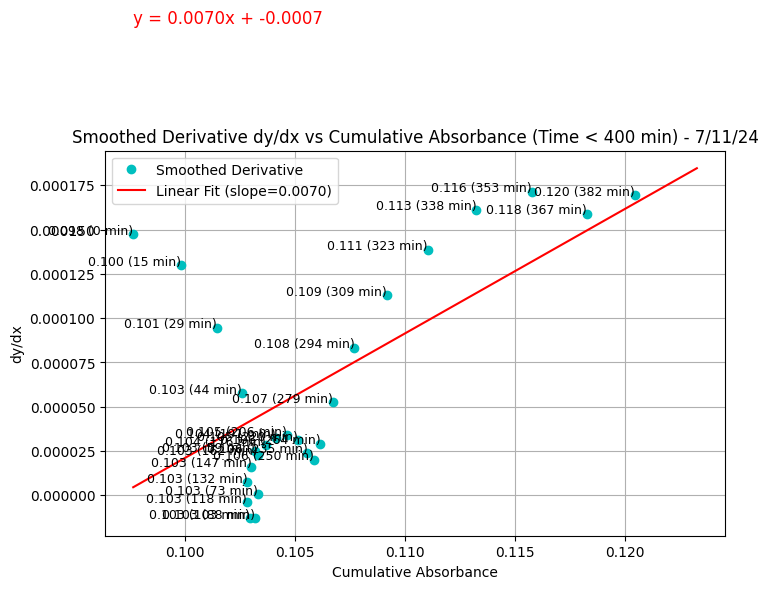

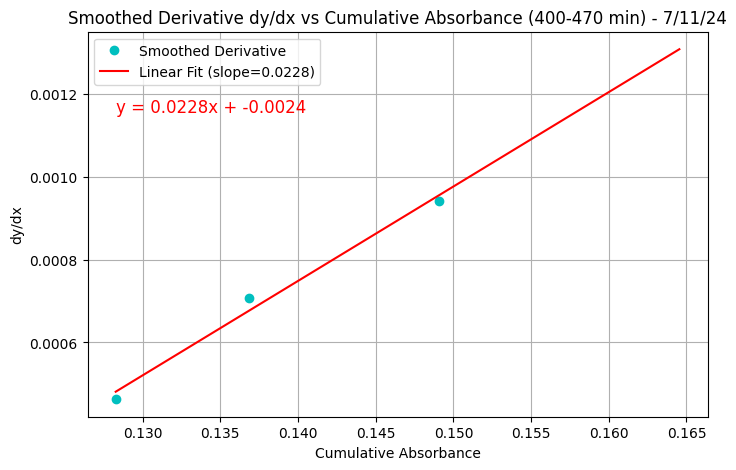

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress
import pandas as pd

# Given Data
data = {
    "7/11/24": [
        ("14:10", 0.093), ("14:51", 0.106), ("15:25", 0.106), ("16:10", 0.1),
        ("16:53", 0.105), ("18:10", 0.114), ("18:55", 0.108), ("20:35", 0.191),
        ("21:05", 0.159), ("22:37", 0.968), ("23:10", 1.091), ("23:44", 1.287),
        ("00:18", 1.316), ("01:36", 1.366), ("02:10", 1.349)
    ]

}

# Function to convert time to minutes since the first recorded time of the day
def convert_time_to_minutes(times):
    base_time = datetime.datetime.strptime(times[0], "%H:%M")
    return [(datetime.datetime.strptime(t, "%H:%M") - base_time).seconds / 60 for t in times]

# Process and plot data for each date
for date, values in data.items():
    times, absorbance = zip(*values)
    x_values = convert_time_to_minutes(times)
    y_values = np.array(absorbance)

    # Regularize x-axis and interpolate
    x_new = np.linspace(min(x_values), max(x_values), num=50)
    y_interpolated = np.interp(x_new, x_values, y_values)

    # Moving average smoothing
    window_size = 3
    y_smooth = np.convolve(y_interpolated, np.ones(window_size)/window_size, mode='valid')
    x_smooth = x_new[:len(y_smooth)]

    # Compute cumulative absorbance
    y_cumulative = np.cumsum(y_smooth) / np.arange(1, len(y_smooth) + 1)

    # Compute derivatives from cumulative absorbance
    dy_dx_smooth = np.gradient(y_cumulative, x_smooth)

    # Annotate y-values with corresponding x-values
    y_annotated = [f"{y:.3f} ({x:.0f} min)" for x, y in zip(x_smooth, y_cumulative)]

    # Plot dy/dx vs y with y-values labeled with time
    plt.figure(figsize=(8, 5))
    plt.plot(y_cumulative[:-1], dy_dx_smooth[:-1], 'mo', label='Smoothed Derivative')
    for i in range(len(y_cumulative) - 1):
        plt.text(y_cumulative[i], dy_dx_smooth[i], y_annotated[i], fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance - {date}')
    plt.legend()
    plt.grid()
    plt.show()

    # Filter data for time < 400 minutes
    mask = np.array(x_smooth) < 400
    x_filtered = np.array(x_smooth)[mask]
    y_filtered = np.array(y_cumulative)[mask]
    dy_dx_filtered = np.array(dy_dx_smooth)[mask]

    # Linear fit for dy/dx vs y graph (time < 400 min)
    slope, intercept, _, _, _ = linregress(y_filtered[:-1], dy_dx_filtered[:-1])
    y_fit = np.linspace(min(y_filtered), max(y_filtered), 50)
    dy_dx_fit = slope * y_fit + intercept

    # Plot filtered dy/dx vs y with linear fit (time < 400 min)
    plt.figure(figsize=(8, 5))
    plt.plot(y_filtered[:-1], dy_dx_filtered[:-1], 'co', label='Smoothed Derivative')
    plt.plot(y_fit, dy_dx_fit, 'r-', label=f'Linear Fit (slope={slope:.4f})')
    for i in range(len(y_filtered) - 1):
        plt.text(y_filtered[i], dy_dx_filtered[i], f"{y_filtered[i]:.3f} ({x_filtered[i]:.0f} min)", fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (Time < 400 min) - {date}')
    plt.legend()
    plt.grid()
    plt.text(min(y_filtered), max(dy_dx_filtered), f"y = {slope:.4f}x + {intercept:.4f}", fontsize=12, color='red')
    plt.show()

    # Filter data for time 400-470 min
    mask_400_470 = (np.array(x_smooth) >= 400) & (np.array(x_smooth) < 470)
    x_filtered_400_470 = np.array(x_smooth)[mask_400_470]
    y_filtered_400_470 = np.array(y_cumulative)[mask_400_470]
    dy_dx_filtered_400_470 = np.array(dy_dx_smooth)[mask_400_470]

    if len(y_filtered_400_470) > 1:
        slope_400_470, intercept_400_470, _, _, _ = linregress(y_filtered_400_470[:-1], dy_dx_filtered_400_470[:-1])
        y_fit_400_470 = np.linspace(min(y_filtered_400_470), max(y_filtered_400_470), 50)
        dy_dx_fit_400_470 = slope_400_470 * y_fit_400_470 + intercept_400_470

        plt.figure(figsize=(8, 5))
        plt.plot(y_filtered_400_470[:-1], dy_dx_filtered_400_470[:-1], 'co', label='Smoothed Derivative')
        plt.plot(y_fit_400_470, dy_dx_fit_400_470, 'r-', label=f'Linear Fit (slope={slope_400_470:.4f})')
        plt.xlabel('Cumulative Absorbance')
        plt.ylabel('dy/dx')
        plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (400-470 min) - {date}')
        plt.legend()
        plt.grid()
        plt.text(min(y_filtered_400_470), max(dy_dx_filtered_400_470), f"y = {slope_400_470:.4f}x + {intercept_400_470:.4f}", fontsize=12, color='red')
        plt.show()

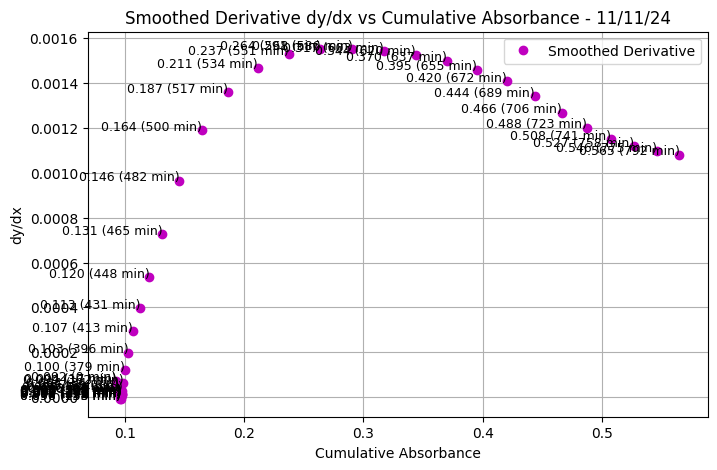

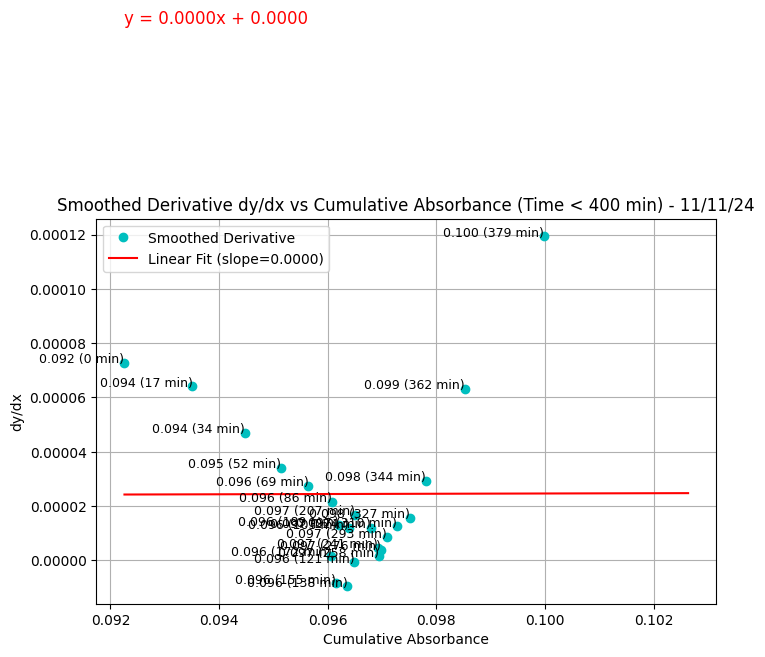

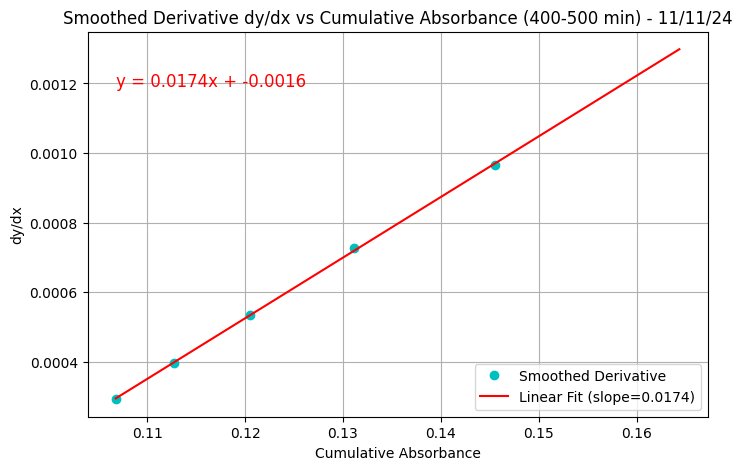

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress
import pandas as pd

# Given Data
data = {

    "11/11/24": [
        ("11:41", 0.089), ("12:18", 0.096), ("13:15", 0.098), ("13:50", 0.099),
        ("14:30", 0.093), ("14:55", 0.095), ("15:34", 0.103), ("16:14", 0.096),
        ("16:45", 0.098), ("17:10", 0.101), ("18:00", 0.105), ("18:45", 0.176),
        ("19:45", 0.39), ("20:25", 0.794), ("21:06", 1.072), ("21:45", 1.208),
        ("22:19", 1.301), ("22:45", 1.362), ("23:25", 1.404), ("00:10", 1.367),
        ("00:45", 1.386), ("01:10", 1.428), ("01:45", 1.477)
    ]

}

# Function to convert time to minutes since the first recorded time of the day
def convert_time_to_minutes(times):
    base_time = datetime.datetime.strptime(times[0], "%H:%M")
    return [(datetime.datetime.strptime(t, "%H:%M") - base_time).seconds / 60 for t in times]

# Process and plot data for each date
for date, values in data.items():
    times, absorbance = zip(*values)
    x_values = convert_time_to_minutes(times)
    y_values = np.array(absorbance)

    # Regularize x-axis and interpolate
    x_new = np.linspace(min(x_values), max(x_values), num=50)
    y_interpolated = np.interp(x_new, x_values, y_values)

    # Moving average smoothing
    window_size = 3
    y_smooth = np.convolve(y_interpolated, np.ones(window_size)/window_size, mode='valid')
    x_smooth = x_new[:len(y_smooth)]

    # Compute cumulative absorbance
    y_cumulative = np.cumsum(y_smooth) / np.arange(1, len(y_smooth) + 1)

    # Compute derivatives from cumulative absorbance
    dy_dx_smooth = np.gradient(y_cumulative, x_smooth)

    # Annotate y-values with corresponding x-values
    y_annotated = [f"{y:.3f} ({x:.0f} min)" for x, y in zip(x_smooth, y_cumulative)]

    # Plot dy/dx vs y with y-values labeled with time
    plt.figure(figsize=(8, 5))
    plt.plot(y_cumulative[:-1], dy_dx_smooth[:-1], 'mo', label='Smoothed Derivative')
    for i in range(len(y_cumulative) - 1):
        plt.text(y_cumulative[i], dy_dx_smooth[i], y_annotated[i], fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance - {date}')
    plt.legend()
    plt.grid()
    plt.show()

    # Filter data for time < 400 minutes
    mask = np.array(x_smooth) < 400
    x_filtered = np.array(x_smooth)[mask]
    y_filtered = np.array(y_cumulative)[mask]
    dy_dx_filtered = np.array(dy_dx_smooth)[mask]

    # Linear fit for dy/dx vs y graph (time < 400 min)
    slope, intercept, _, _, _ = linregress(y_filtered[:-1], dy_dx_filtered[:-1])
    y_fit = np.linspace(min(y_filtered), max(y_filtered), 50)
    dy_dx_fit = slope * y_fit + intercept

    # Plot filtered dy/dx vs y with linear fit (time < 400 min)
    plt.figure(figsize=(8, 5))
    plt.plot(y_filtered[:-1], dy_dx_filtered[:-1], 'co', label='Smoothed Derivative')
    plt.plot(y_fit, dy_dx_fit, 'r-', label=f'Linear Fit (slope={slope:.4f})')
    for i in range(len(y_filtered) - 1):
        plt.text(y_filtered[i], dy_dx_filtered[i], f"{y_filtered[i]:.3f} ({x_filtered[i]:.0f} min)", fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (Time < 400 min) - {date}')
    plt.legend()
    plt.grid()
    plt.text(min(y_filtered), max(dy_dx_filtered), f"y = {slope:.4f}x + {intercept:.4f}", fontsize=12, color='red')
    plt.show()

    # Filter data for time 400-500 min
    mask_400_500 = (np.array(x_smooth) >= 400) & (np.array(x_smooth) < 500)
    x_filtered_400_500 = np.array(x_smooth)[mask_400_500]
    y_filtered_400_500 = np.array(y_cumulative)[mask_400_500]
    dy_dx_filtered_400_500 = np.array(dy_dx_smooth)[mask_400_500]

    if len(y_filtered_400_500) > 1:
        slope_400_500, intercept_400_500, _, _, _ = linregress(y_filtered_400_500[:-1], dy_dx_filtered_400_500[:-1])
        y_fit_400_500 = np.linspace(min(y_filtered_400_500), max(y_filtered_400_500), 50)
        dy_dx_fit_400_500 = slope_400_500 * y_fit_400_500 + intercept_400_500

        plt.figure(figsize=(8, 5))
        plt.plot(y_filtered_400_500[:-1], dy_dx_filtered_400_500[:-1], 'co', label='Smoothed Derivative')
        plt.plot(y_fit_400_500, dy_dx_fit_400_500, 'r-', label=f'Linear Fit (slope={slope_400_500:.4f})')
        plt.xlabel('Cumulative Absorbance')
        plt.ylabel('dy/dx')
        plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (400-500 min) - {date}')
        plt.legend()
        plt.grid()
        plt.text(min(y_filtered_400_500), max(dy_dx_filtered_400_500), f"y = {slope_400_500:.4f}x + {intercept_400_500:.4f}", fontsize=12, color='red')
        plt.show()

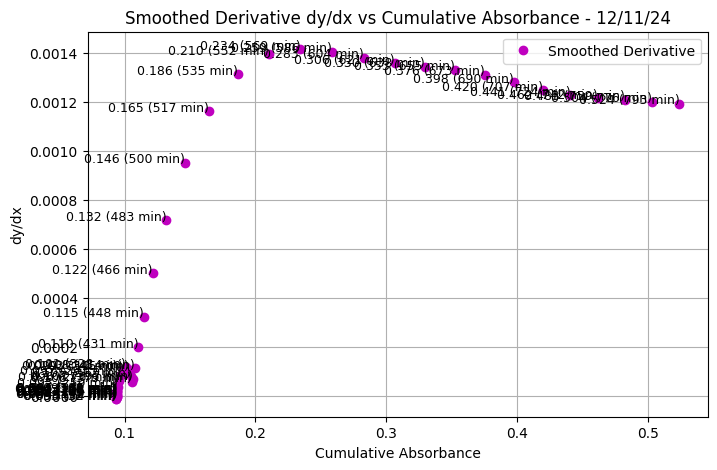

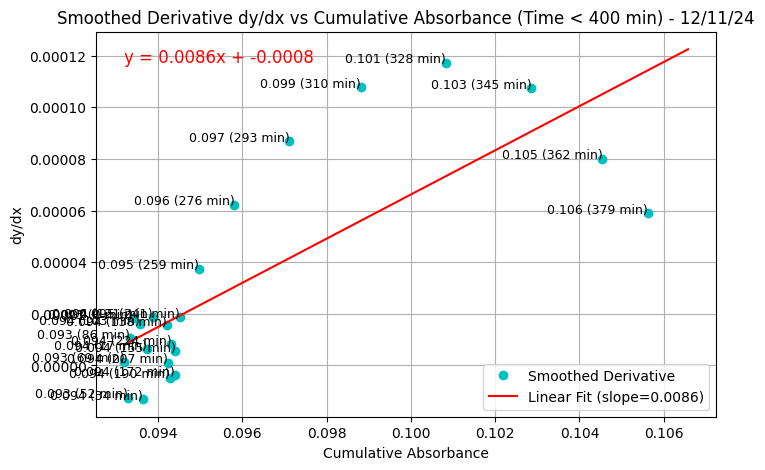

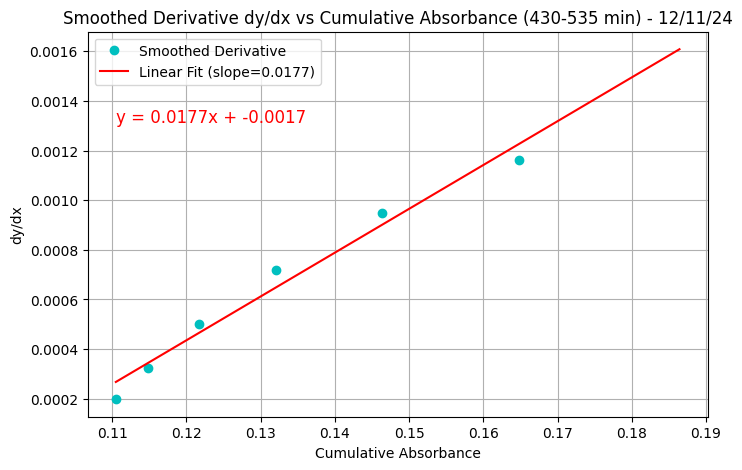

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress
import pandas as pd

# Given Data
data = {

    "12/11/24": [
        ("11:55", 0.09), ("12:28", 0.097), ("12:50", 0.091), ("14:45", 0.098),
        ("15:20", 0.091), ("15:56", 0.096), ("16:27", 0.097), ("18:00", 0.151),
        ("18:51", 0.116), ("19:32", 0.179), ("20:06", 0.331), ("20:42", 0.647),
        ("21:15", 0.947), ("21:45", 1.061), ("22:20", 1.134), ("22:54", 1.19),
        ("23:25", 1.275), ("00:25", 1.339), ("01:00", 1.425), ("01:30", 1.48),
        ("02:00", 1.541)
    ]

}

# Function to convert time to minutes since the first recorded time of the day
def convert_time_to_minutes(times):
    base_time = datetime.datetime.strptime(times[0], "%H:%M")
    return [(datetime.datetime.strptime(t, "%H:%M") - base_time).seconds / 60 for t in times]

# Process and plot data for each date
for date, values in data.items():
    times, absorbance = zip(*values)
    x_values = convert_time_to_minutes(times)
    y_values = np.array(absorbance)

    # Regularize x-axis and interpolate
    x_new = np.linspace(min(x_values), max(x_values), num=50)
    y_interpolated = np.interp(x_new, x_values, y_values)

    # Moving average smoothing
    window_size = 3
    y_smooth = np.convolve(y_interpolated, np.ones(window_size)/window_size, mode='valid')
    x_smooth = x_new[:len(y_smooth)]

    # Compute cumulative absorbance
    y_cumulative = np.cumsum(y_smooth) / np.arange(1, len(y_smooth) + 1)

    # Compute derivatives from cumulative absorbance
    dy_dx_smooth = np.gradient(y_cumulative, x_smooth)

    # Annotate y-values with corresponding x-values
    y_annotated = [f"{y:.3f} ({x:.0f} min)" for x, y in zip(x_smooth, y_cumulative)]

    # Plot dy/dx vs y with y-values labeled with time
    plt.figure(figsize=(8, 5))
    plt.plot(y_cumulative[:-1], dy_dx_smooth[:-1], 'mo', label='Smoothed Derivative')
    for i in range(len(y_cumulative) - 1):
        plt.text(y_cumulative[i], dy_dx_smooth[i], y_annotated[i], fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance - {date}')
    plt.legend()
    plt.grid()
    plt.show()

    # Filter data for time < 400 minutes
    mask = np.array(x_smooth) < 400
    x_filtered = np.array(x_smooth)[mask]
    y_filtered = np.array(y_cumulative)[mask]
    dy_dx_filtered = np.array(dy_dx_smooth)[mask]

    # Linear fit for dy/dx vs y graph (time < 400 min)
    slope, intercept, _, _, _ = linregress(y_filtered[:-1], dy_dx_filtered[:-1])
    y_fit = np.linspace(min(y_filtered), max(y_filtered), 50)
    dy_dx_fit = slope * y_fit + intercept

    # Plot filtered dy/dx vs y with linear fit (time < 400 min)
    plt.figure(figsize=(8, 5))
    plt.plot(y_filtered[:-1], dy_dx_filtered[:-1], 'co', label='Smoothed Derivative')
    plt.plot(y_fit, dy_dx_fit, 'r-', label=f'Linear Fit (slope={slope:.4f})')
    for i in range(len(y_filtered) - 1):
        plt.text(y_filtered[i], dy_dx_filtered[i], f"{y_filtered[i]:.3f} ({x_filtered[i]:.0f} min)", fontsize=9, ha='right')
    plt.xlabel('Cumulative Absorbance')
    plt.ylabel('dy/dx')
    plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (Time < 400 min) - {date}')
    plt.legend()
    plt.grid()
    plt.text(min(y_filtered), max(dy_dx_filtered), f"y = {slope:.4f}x + {intercept:.4f}", fontsize=12, color='red')
    plt.show()

    # Filter data for time 430-535min
    mask_430_535 = (np.array(x_smooth) >= 430) & (np.array(x_smooth) < 535)
    x_filtered_400_500 = np.array(x_smooth)[mask_430_535]
    y_filtered_430_535 = np.array(y_cumulative)[mask_430_535]
    dy_dx_filtered_430_535 = np.array(dy_dx_smooth)[mask_430_535]

    if len(y_filtered_430_535) > 1:
        slope_430_535, intercept_430_535, _, _, _ = linregress(y_filtered_430_535[:-1], dy_dx_filtered_430_535[:-1])
        y_fit_430_535 = np.linspace(min(y_filtered_430_535), max(y_filtered_430_535), 50)
        dy_dx_fit_430_535 = slope_430_535 * y_fit_430_535 + intercept_430_535

        plt.figure(figsize=(8, 5))
        plt.plot(y_filtered_430_535[:-1], dy_dx_filtered_430_535[:-1], 'co', label='Smoothed Derivative')
        plt.plot(y_fit_430_535, dy_dx_fit_430_535, 'r-', label=f'Linear Fit (slope={slope_430_535:.4f})')
        plt.xlabel('Cumulative Absorbance')
        plt.ylabel('dy/dx')
        plt.title(f'Smoothed Derivative dy/dx vs Cumulative Absorbance (430-535 min) - {date}')
        plt.legend()
        plt.grid()
        plt.text(min(y_filtered_430_535), max(dy_dx_filtered_430_535), f"y = {slope_430_535:.4f}x + {intercept_430_535:.4f}", fontsize=12, color='red')
        plt.show()